In [1]:
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

#### 2.6.1 A Simple Example: Tossing Coins

In [2]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [45, 55]


In [3]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([49., 51.])

In [4]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.5100, 0.4900])

In [6]:
counts = Multinomial(10000, fair_probs).sample()
counts / 10000

tensor([0.4941, 0.5059])

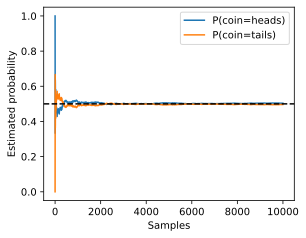

In [7]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

In [8]:
# exercise_1
## Normally, according to law of large numbers, observing more data leads to the reduction of uncertainty.
## For example, coin toss, die roll, weather prediction, and so on.
## However, if the space of interval is with bias, or the uncertainty is extremely high or the model is not proper,
## enlarging the space of sample will not help.

In [9]:
# exercise_2
## In case of random uncertainty and system uncertainty, for example, when measuring object's length.
## If we only measure by certain tool, the final uncertainty depends on its precision.

In [10]:
# exercise_3
## Var(once) = E(once^2) - E(once)^2 = (1-p)^2 * p + (0-p)^2 * (1-p) = p(1-p)
## Var(n-times) = sum(Var(ones)) = np(1-p) = 0.25n
# exercise_3_1
## As the formula shows, variance increase linearly along with the increase of n.
# exercise_3_2
## σ = (np(1-p))^0.5  μ = np
## thus [np-(2np(1-p))^0.5, np + (2np(1-p))^0.5]
# exercise_3_3
## Since each toss is independent, has the same possibility and has variance, when n is large enough, 
## these vatiations' summation or mean is about normally distributed, 
## which is named central limit theorem.

In [11]:
# exercise_4
## z_m has the same distribution with x_i, which has zero mean and unit variance.
## Could not. Cause the set of z_m follows the distribution rather every z_m.

In [12]:
# exercise_5
## max(P(A), P(B)) <= P(AUB) <= P(A) +P(B)
## 0 <= P(A∩B) <= min(P(A), P(B))

In [14]:
# exercise_6
## Since it is a Markov chain, C and A are independent.
## P(A, B, C) = P(AC|B)P(B) = P(A|B)P(C|B)P(B)                                                                 (???)

In [16]:
# exercise_7
# exercise_7_1
## P(D_1=1|H=0) = P(D_2=1|H=0) = P(D=1|H=0) = 0.1
## P(D_1=0|H=0) = P(D_2=0|H=0) = 1 - 0.1 = 0.9
# exercise_7_2
## P(H=0) = 1 - P(H=1) = 0.9985
## P(H=1, D_1=1) = P(D_1=1|H=1)P(H=1) = (1 - P(D_1=0|H=1))P(H=1) = (1 - P(D=0|H=1))P(H=1) = (1 - 0.01)*0.0015
## P(H=0, D_1=1) = P(D_1=1|H=0)P(H=0) = 0.1*0.9985
## P(D_1=1) = P(D_1=1, H=0) + P(D_1=1, H=1) = 0.1*0.9985 + 0.99*0.0015
## P(H=1|D_1=1) = P(H=1, D_1=1)/P(D_1=1) = (0.99*0.0015)/(0.1*0.9985 + 0.99*0.0015)
# exercise_7_3
## P(H=0, D_1=1, D_2=1) = P(D_1=1, D_2=1|H=0)P(H=0) = 0.02*0.9985
## P(H=1, D_1=1, D_2=1) = 1 - P(H=0, D_1=1, D_2=1) = 1 - 0.02*0.9985
## P(D_1=1, D_2=1|H=1) = P(D_1=1|H=1)P(D_2=1|H=1) = (1 - P(D_1=0|H=1))(1 - P(D_2=0|H=1)) = 0.99*0.99
## P(D_1=1, D_2=1) = P(D_1=1, D_2=1|H=1)P(H=1) = 0.99*0.99*0.0015
## P(H=1|D_1=1, D_2=1) = P(H=1, D_1=1, D_2=1)/P(D_1=1, D_2=1) = (1 - 0.02*0.9985)/(0.99*0.99*0.0015)

In [17]:
# exercise_8
# exercise_8_1
## expectation = sum(α*s*p[s])
# exercise_8_2
## Invest more in higher return choices.
## Consider the covariance.
## If the Cov between some choices is positive, these choices are likely to win or lose together, 
## while a negative Cov means that the choices will have opposing tendency.
## In conclusion, we may invest choices that have negative Cov to reduce loss.
# exercise_8_3
## Σ(i, j) = Cov(α_i*s_i, α_j*s_j) = α_i*s_i*α_j*s_j * (p[s_i, s_j] - p[s_i]*p[s_j])
# exercise_8_4
## List out the restriction conditions and throw them into solver?